# PCA


Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that transforms a dataset into a new coordinate system to maximize variance along new axes (principal components). The main goal is to reduce dimensionality while retaining as much information (variance) as possible.

The algorithm works as follows:

#### Standardize the data

Subtract the mean of each feature to center the data (zero mean).

#### Compute the covariance matrix
This captures the relationships between features.

#### Find eigenvalues and eigenvectors
Eigenvectors define the principal components, eigenvalues represent the amount of variance captured by each.

#### Sort components by variance
Components are ranked by eigenvalues from largest to smallest.

#### Project the data
The original data is transformed onto the new set of top n principal components.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from collections import deque
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the PCA works on the data. While this visualization choice limits the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

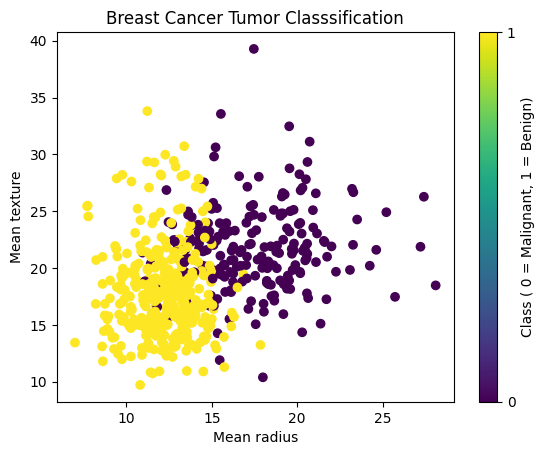

In [12]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [13]:
class SimplePCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None

    def fit(self, X):
        # Step 1: Standardize the data
        X = X - np.mean(X, axis=0)

        # Step 2: Compute the covariance matrix
        cov_matrix = np.cov(X, rowvar=False)

        # Step 3: Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Step 4: Sort eigenvectors by decreasing eigenvalues
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Store top n_components
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]

    def transform(self, X):
        X = X - np.mean(X, axis=0)
        return np.dot(X, self.components_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [14]:
#Scalling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

In [15]:
#Implementing custom PCA
pca = SimplePCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: {pca.explained_variance_}")

# All eigenvalues (from full PCA)
eigenvalues, _ = np.linalg.eigh(np.cov(X_scaled, rowvar=False))
eigenvalues = eigenvalues[::-1]  # sort descending

total_variance = np.sum(eigenvalues)
explained_variance_ratio = pca.explained_variance_ / total_variance

print(f"Explained variance ratio: {explained_variance_ratio}")
print(f"Cumulative explained variance: {np.cumsum(explained_variance_ratio)}")

Explained variance: [13.30499079  5.7013746 ]
Explained variance ratio: [0.44272026 0.18971182]
Cumulative explained variance: [0.44272026 0.63243208]


In [16]:
# Implementing sklearn PCA
sklearn_pca = PCA(n_components=2)
X_pca_sklearn = sklearn_pca.fit_transform(X_scaled)
print(f"Sklearn PCA - Explained variance: {sklearn_pca.explained_variance_}")
print(f"Sklearn PCA - Explained variance ratio: {sklearn_pca.explained_variance_ratio_}")
print(f"Sklearn PCA - Cumulative explained variance: {np.cumsum(sklearn_pca.explained_variance_ratio_)}")

Sklearn PCA - Explained variance: [13.30499079  5.7013746 ]
Sklearn PCA - Explained variance ratio: [0.44272026 0.18971182]
Sklearn PCA - Cumulative explained variance: [0.44272026 0.63243208]


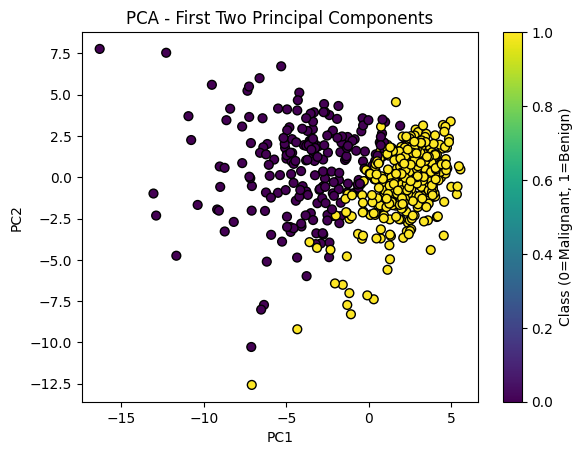

In [17]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - First Two Principal Components')
plt.colorbar(label='Class (0=Malignant, 1=Benign)')
plt.show()


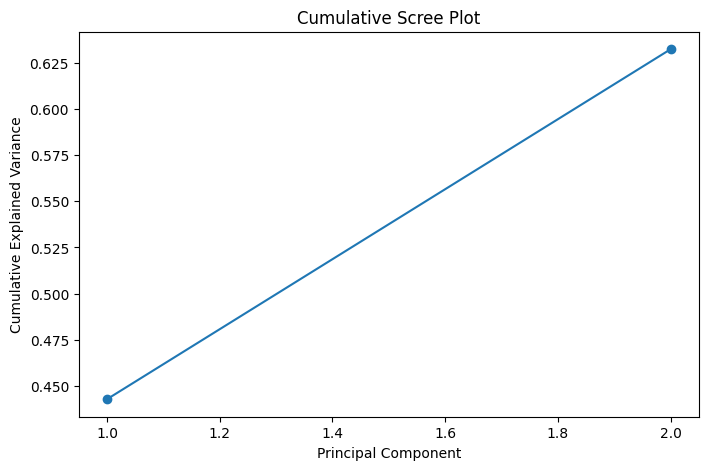

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(sklearn_pca.explained_variance_ratio_)+1),
         np.cumsum(sklearn_pca.explained_variance_ratio_), marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Scree Plot')
plt.show()


The first two principal components captured approximately:

PC1: ~44% of the total variance,

PC2: ~19% of the total variance,

Combined: ~63% of the dataset’s total variance.

This means that a 2D projection retains a substantial portion of the dataset’s information, making it useful for visualization and initial exploratory insights. Moreover, our numbers match those of sklearn, which shows the quality ofn the custom PCA model.

The scatter plot of the first two principal components shows some visible separation between malignant and benign tumors. However, the overlap indicates that PCA alone doesn’t perfectly separate the classes, which is expected because PCA is unsupervised and optimizes variance, not classification.

The explained variance plot shows that while the first few components carry a large share of the variance, capturing close to 100% of the dataset’s complexity requires more components.